In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import date

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="darkgrid")
%matplotlib inline

# Load all CSV files from the data folder in one cell
data_dir = Path("data")

employees = pd.read_csv(data_dir / "BOLT_Employees.csv")
changes = pd.read_csv(data_dir / "BOLT_EmployeeChanges.csv")
performance = pd.read_csv(data_dir / "BOLT_Performance.csv")
applicants = pd.read_csv(data_dir / "BOLT_Applicants.csv")
branch = pd.read_csv(data_dir / "BOLT_Branch.csv")

# Parse date columns
if "HiredOn" in employees.columns:
    employees["HiredOn"] = pd.to_datetime(employees["HiredOn"], errors="coerce")

if "DateChanged" in changes.columns:
    changes["DateChanged"] = pd.to_datetime(changes["DateChanged"], errors="coerce")

if "DateReviewed" in performance.columns:
    performance["DateReviewed"] = pd.to_datetime(performance["DateReviewed"], errors="coerce")

if "DatePosted" in branch.columns:
    branch["DatePosted"] = pd.to_datetime(branch["DatePosted"], errors="coerce")

print("Loaded shapes:")
print("employees:", employees.shape)
print("changes:", changes.shape)
print("performance:", performance.shape)
print("applicants:", applicants.shape)
print("branch:", branch.shape)

display(employees.head())
display(changes.head())
display(performance.head())
display(applicants.head())
display(branch.head())

Loaded shapes:
employees: (1067, 9)
changes: (1165, 4)
performance: (2189, 3)
applicants: (10500, 6)
branch: (1049, 7)


,EmployeeID,Wage,HiredOn,Branch#,Current status,Position,Role,AvgWorkingHours/Week,ApplicantID
0,5764,Minimum,2022-06-13,1,Working,full-time,Manager,48.8,107642
1,5997,Minimum,2024-02-26,1,Working,full-time,Manager,50.4,109966
2,5454,Competitive,2024-06-20,1,Working,full-time,Manager,49.2,104693
3,5557,Competitive,2024-09-04,1,Working,full-time,Manager,52.0,105628
4,5923,Minimum,2024-12-07,1,Working,full-time,Manager,48.6,109352


,EmployeeID,New Role,DateChanged,ReasonForLeaving
0,5000,Quit,2024-10-07,Poor Management
1,5001,Quit,2025-02-01,Better Offer
2,5002,Quit,2022-06-25,Lack of Growth
3,5003,Quit,2025-11-05,Poor Management
4,5005,Quit,2025-03-21,Lack of Growth


,EmployeeID,DateReviewed,PerformanceScore
0,5764,2022-09-11,88.22
1,5764,2022-12-10,88.86
2,5764,2023-03-10,87.28
3,5764,2023-06-08,91.00
4,5764,2023-09-06,92.23


,ApplicantID,PastRelevantExperience,YearsOfRelevantExperience,HighestEducationLevel,YearOfBirth,Hired
0,100000,True,2,High School,2003,False
1,100001,True,2,Bachelor,2002,True
2,100002,True,2,High School,2007,False
3,100003,True,2,High School,2007,False
4,100004,True,1,High School,1998,False


,Branch#,BranchName,Latitude,Longitude,ReviewText,Stars,DatePosted
0,1,UBC,49.2606,-123.246,Absolutely love this place!,5,2025-12-30
1,1,UBC,49.2606,-123.246,So glad I found this place.,4,2021-02-19
2,1,UBC,49.2606,-123.246,Best service in town.,4,2021-03-17
3,1,UBC,49.2606,-123.246,Always a pleasant experience.,4,2022-12-03
4,1,UBC,49.2606,-123.246,The pastries are amazing.,4,2021-06-17


### Employees Data

In [2]:
print(employees.dtypes)
employees.info()

EmployeeID                       int64
Wage                               str
HiredOn                 datetime64[us]
Branch#                          int64
Current status                     str
Position                           str
Role                               str
AvgWorkingHours/Week           float64
ApplicantID                      int64
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   EmployeeID            1067 non-null   int64         
 1   Wage                  1067 non-null   str           
 2   HiredOn               1067 non-null   datetime64[us]
 3   Branch#               1067 non-null   int64         
 4   Current status        1067 non-null   str           
 5   Position              1067 non-null   str           
 6   Role                  1067 non-null   str           
 7   AvgWorkingHou

In [3]:
# Duplicates
print("Duplicate rows:", employees.duplicated().sum())
print("Duplicate EmployeeIDs:", employees["EmployeeID"].duplicated().sum())

Duplicate rows: 0
Duplicate EmployeeIDs: 0


           count       mean       std   min   25%   50%   75%   max
Position                                                           
full-time  609.0  38.506732  4.754579  29.2  35.3  37.7  40.2  52.5
part-time  458.0  19.534934  3.069751  12.1  17.7  19.2  21.2  28.2


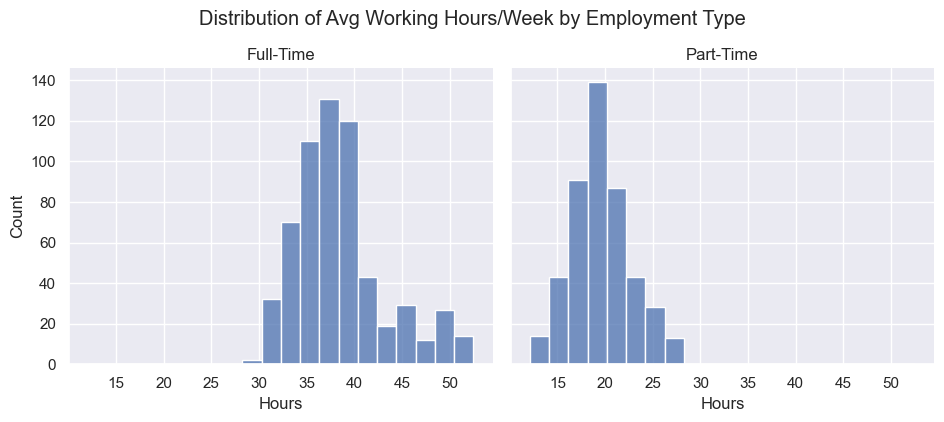

In [4]:
plot_df = employees.dropna(subset=["AvgWorkingHours/Week", "Position"]).copy()
plot_df["Position"] = plot_df["Position"].str.title()

g = sns.displot(
    data=plot_df,
    x="AvgWorkingHours/Week",
    col="Position",
    col_order=["Full-Time", "Part-Time"],
    bins=20,
    height=4,
    aspect=1.2,
)

g.set_axis_labels("Hours", "Count")
g.set_titles("{col_name}")
g.figure.suptitle("Distribution of Avg Working Hours/Week by Employment Type", y=1.05)

print(employees.groupby("Position")["AvgWorkingHours/Week"].describe())

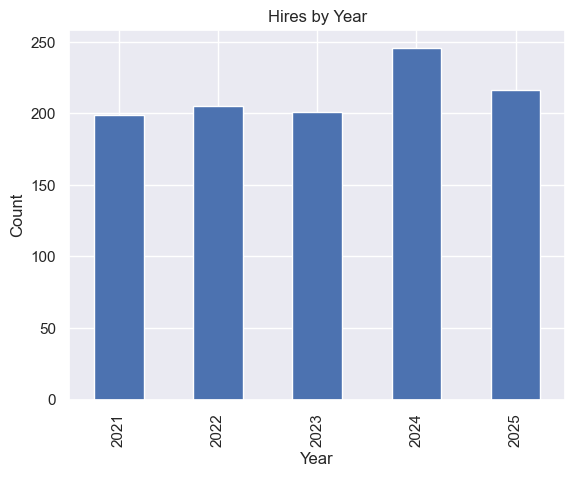

In [5]:
employees["HiredOn"] = pd.to_datetime(employees["HiredOn"])
employees["HireYear"] = employees["HiredOn"].dt.year
employees["HireMonth"] = employees["HiredOn"].dt.month

employees["HireYear"].value_counts().sort_index().plot(kind="bar")
plt.title("Hires by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

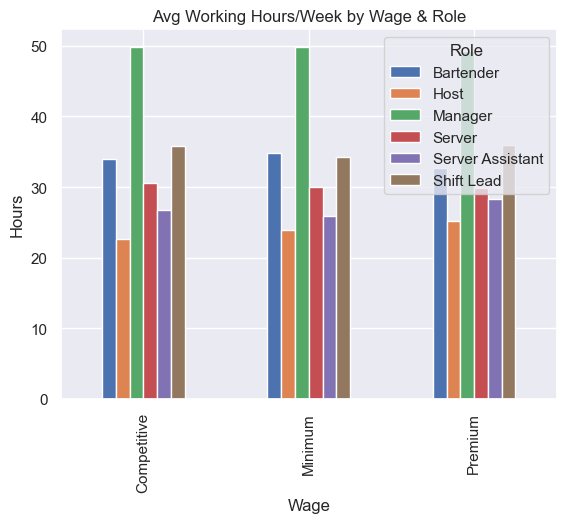

In [6]:
employees.groupby(["Wage", "Role"])["AvgWorkingHours/Week"].mean().unstack().plot(kind="bar")
plt.title("Avg Working Hours/Week by Wage & Role")
plt.ylabel("Hours")
plt.show()

### Employee Changes

In [7]:
changes.info()

<class 'pandas.DataFrame'>
RangeIndex: 1165 entries, 0 to 1164
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   EmployeeID        1165 non-null   int64         
 1   New Role          1165 non-null   str           
 2   DateChanged       1165 non-null   datetime64[us]
 3   ReasonForLeaving  942 non-null    str           
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 36.5 KB


In [8]:
print("Duplicate rows:", changes.duplicated().sum())

Duplicate rows: 0


In [9]:
for col in ["New Role", "ReasonForLeaving"]:
    print(f"\n--- {col} ---")
    print(changes[col].value_counts())


--- New Role ---
New Role
Quit                803
Dismissed           139
Bartender           117
Server               36
Manager              34
Shift Lead           31
Server Assistant      5
Name: count, dtype: int64

--- ReasonForLeaving ---
ReasonForLeaving
Better Offer          231
Lack of Growth        169
Burntout              124
Insufficient Wages    119
Poor Management       114
Performance            85
Relocation             46
Attendance             30
Policy Violation       24
Name: count, dtype: int64


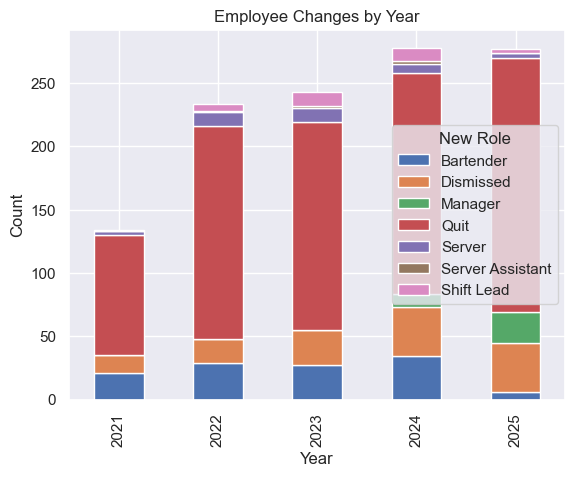

In [10]:
changes["ChangeYear"] = changes["DateChanged"].dt.year

changes.groupby('ChangeYear')["New Role"].value_counts().sort_index().unstack().plot(kind="bar", stacked=True)
plt.title("Employee Changes by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

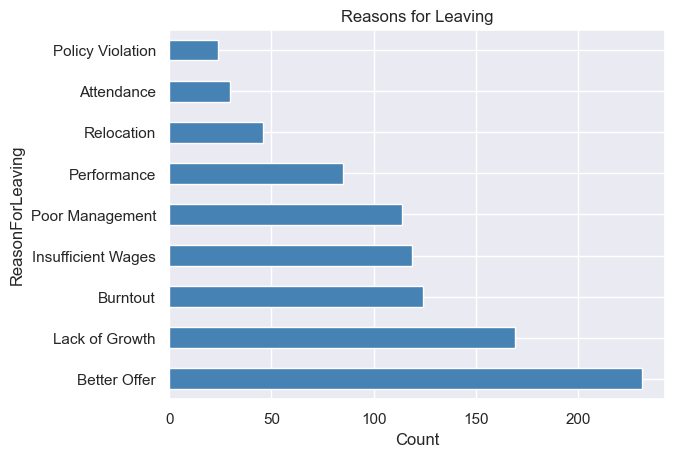

In [11]:
changes["ReasonForLeaving"].value_counts().plot(kind="barh", color="steelblue")
plt.title("Reasons for Leaving")
plt.xlabel("Count")
plt.show()

In [12]:
orphaned = changes[~changes["EmployeeID"].isin(employees["EmployeeID"])]
print(f"Changes records with no matching employee: {len(orphaned)}")

Changes records with no matching employee: 0


### Performance

In [13]:
performance.info()

<class 'pandas.DataFrame'>
RangeIndex: 2189 entries, 0 to 2188
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   EmployeeID        2189 non-null   int64         
 1   DateReviewed      2189 non-null   datetime64[us]
 2   PerformanceScore  2189 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 51.4 KB


In [14]:
print("Duplicate rows:", performance.duplicated().sum())

Duplicate rows: 0


count    1067.000000
mean        2.051546
std         1.881620
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        14.000000
dtype: float64


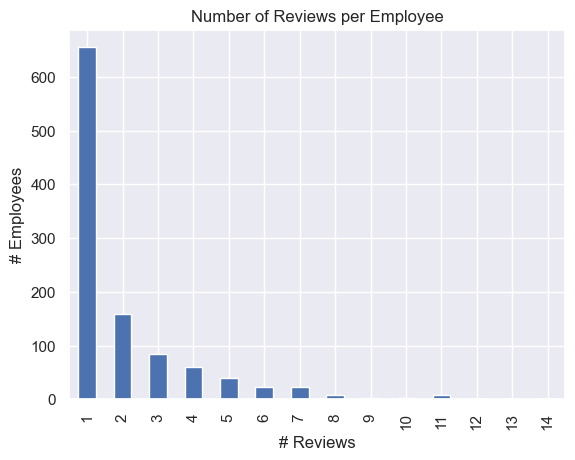

In [15]:
reviews_per_emp = performance.groupby("EmployeeID").size()
print(reviews_per_emp.describe())
reviews_per_emp.value_counts().sort_index().plot(kind="bar")
plt.title("Number of Reviews per Employee")
plt.xlabel("# Reviews")
plt.ylabel("# Employees")
plt.show()

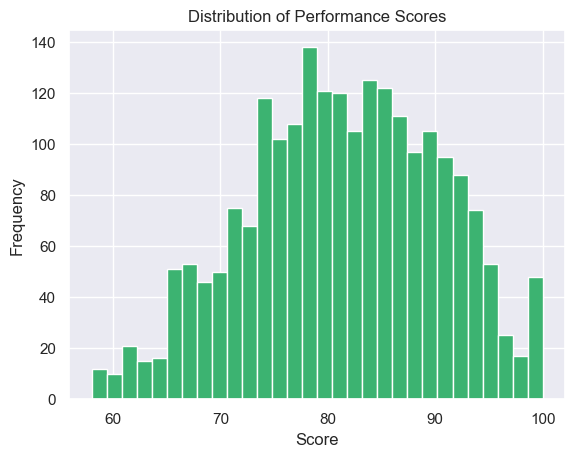

count    2189.000000
mean       81.362878
std         8.986163
min        58.030000
25%        74.980000
50%        81.500000
75%        88.110000
max       100.000000
Name: PerformanceScore, dtype: float64


In [16]:
performance["PerformanceScore"].hist(bins=30, color="mediumseagreen")
plt.title("Distribution of Performance Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

print(performance["PerformanceScore"].describe())

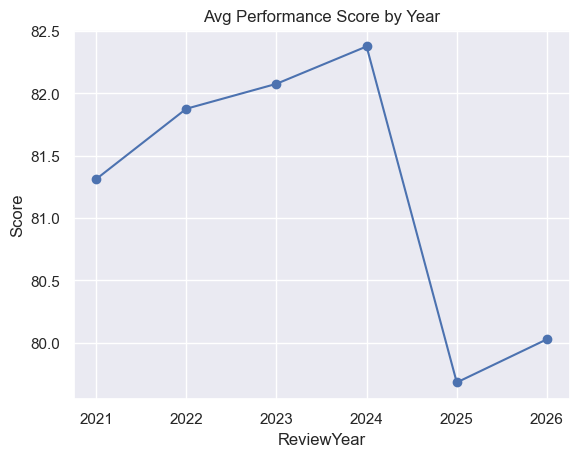

In [17]:
performance["ReviewYear"] = performance["DateReviewed"].dt.year

performance.groupby("ReviewYear")["PerformanceScore"].mean().plot(marker="o")
plt.title("Avg Performance Score by Year")
plt.ylabel("Score")
plt.show()

Year summary:



,n_reviews,mean,median,std,min,max
ReviewYear,,,,,,
2021,215,81.311814,82.080,9.770650,58.19,100.00
2022,416,81.876370,82.075,8.973326,58.91,100.00
2023,418,82.076411,82.970,9.290546,58.03,100.00
2024,518,82.376062,82.390,8.978093,58.59,100.00
2025,566,79.682633,79.690,8.350636,58.07,100.00
2026,56,80.028929,79.855,7.651206,62.92,94.73



2024 vs 2025 comparison:
Mean score change: -2.693 (-3.27%)
Review count change: 48.0 (9.27%)

Monthly trend (2024 vs 2025):


,ReviewYear,ReviewMonth,n_reviews,mean_score
33,2024,2024-01,47,82.113617
34,2024,2024-02,43,84.205814
35,2024,2024-03,28,79.740357
36,2024,2024-04,38,83.281842
37,2024,2024-05,49,83.754082
38,2024,2024-06,28,79.492500
39,2024,2024-07,54,83.607407
40,2024,2024-08,48,81.690625
41,2024,2024-09,36,79.214444
42,2024,2024-10,53,84.666226


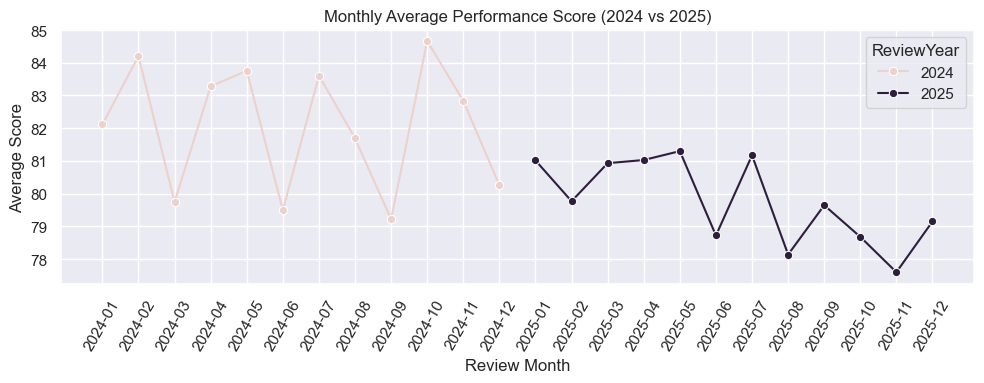

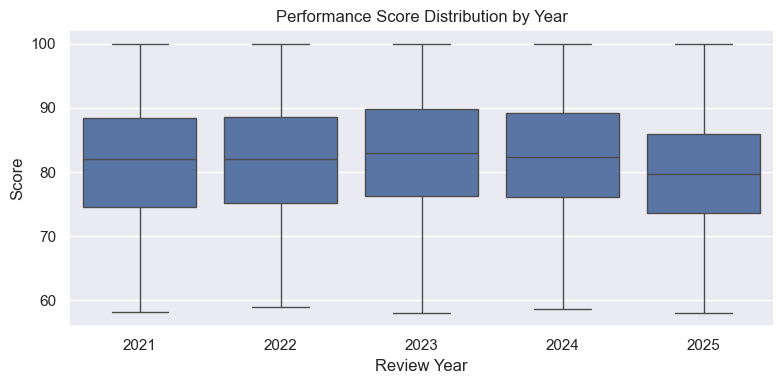


Employee mix among reviewed employees (2024 vs 2025):

Role distribution by year (row %):


Role,Bartender,Host,Manager,Server,Server Assistant,Shift Lead
ReviewYear,,,,,,
2024,37.6,3.1,10.6,24.9,15.3,8.5
2025,18.2,4.2,32.3,19.8,12.5,12.9



Position distribution by year (row %):


Position,full-time,part-time
ReviewYear,,
2024,62.9,37.1
2025,75.6,24.4



Wage distribution by year (row %):


Wage,Competitive,Minimum,Premium
ReviewYear,,,
2024,47.3,39.4,13.3
2025,42.8,44.2,13.1


In [18]:
# Diagnose why average performance score dropped in 2025
if "ReviewYear" not in performance.columns:
    performance["ReviewYear"] = performance["DateReviewed"].dt.year

score_col = "PerformanceScore"
perf = performance.dropna(subset=["DateReviewed", "ReviewYear", score_col]).copy()

# 1) Year-level context: sample size and central tendency
year_summary = (
    perf.groupby("ReviewYear")[score_col]
    .agg(n_reviews="count", mean="mean", median="median", std="std", min="min", max="max")
    .sort_index()
)
print("Year summary:\n")
display(year_summary)

# 2) Direct comparison: 2024 vs 2025
compare_years = [2024, 2025]
if all(y in year_summary.index for y in compare_years):
    y2024 = year_summary.loc[2024]
    y2025 = year_summary.loc[2025]

    mean_change_abs = y2025["mean"] - y2024["mean"]
    mean_change_pct = (mean_change_abs / y2024["mean"]) * 100 if y2024["mean"] != 0 else np.nan
    n_change_abs = y2025["n_reviews"] - y2024["n_reviews"]
    n_change_pct = (n_change_abs / y2024["n_reviews"]) * 100 if y2024["n_reviews"] != 0 else np.nan

    print("\n2024 vs 2025 comparison:")
    print(f"Mean score change: {mean_change_abs:.3f} ({mean_change_pct:.2f}%)")
    print(f"Review count change: {n_change_abs} ({n_change_pct:.2f}%)")

# 3) Monthly pattern to detect partial-year effects
monthly = (
    perf.assign(ReviewMonth=perf["DateReviewed"].dt.to_period("M").astype(str))
    .groupby(["ReviewYear", "ReviewMonth"])[score_col]
    .agg(n_reviews="count", mean_score="mean")
    .reset_index()
)

monthly_2024_2025 = monthly[monthly["ReviewYear"].isin([2024, 2025])]
print("\nMonthly trend (2024 vs 2025):")
display(monthly_2024_2025)

plt.figure(figsize=(10, 4))
sns.lineplot(data=monthly_2024_2025, x="ReviewMonth", y="mean_score", hue="ReviewYear", marker="o")
plt.xticks(rotation=60)
plt.title("Monthly Average Performance Score (2024 vs 2025)")
plt.xlabel("Review Month")
plt.ylabel("Average Score")
plt.tight_layout()
plt.show()

# 4) Score distribution check (shape change, outliers)
plt.figure(figsize=(8, 4))
subset = perf[perf["ReviewYear"].between(2021, 2025)]
sns.boxplot(data=subset, x="ReviewYear", y=score_col)
plt.title("Performance Score Distribution by Year")
plt.xlabel("Review Year")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

# 5) Employee-mix shift check by joining attributes from employees
mix_cols = [c for c in ["Role", "Position", "Wage", "Department", "Branch", "BranchID"] if c in employees.columns]
if mix_cols:
    merged = perf.merge(employees[["EmployeeID"] + mix_cols], on="EmployeeID", how="left")
    print("\nEmployee mix among reviewed employees (2024 vs 2025):")
    for c in mix_cols:
        print(f"\n{c} distribution by year (row %):")
        dist = pd.crosstab(merged["ReviewYear"], merged[c], normalize="index") * 100
        if 2024 in dist.index or 2025 in dist.index:
            display(dist.loc[[y for y in [2024, 2025] if y in dist.index]].round(1))
else:
    print("\nNo employee attribute columns found for mix-shift analysis.")

### Applicants

In [19]:
applicants.info() 

<class 'pandas.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   ApplicantID                10500 non-null  int64
 1   PastRelevantExperience     10500 non-null  bool 
 2   YearsOfRelevantExperience  10500 non-null  int64
 3   HighestEducationLevel      10500 non-null  str  
 4   YearOfBirth                10500 non-null  int64
 5   Hired                      10500 non-null  bool 
dtypes: bool(2), int64(3), str(1)
memory usage: 348.8 KB


In [20]:
print("Duplicate rows:", applicants.duplicated().sum())
print("Duplicate ApplicantIDs:", applicants["ApplicantID"].duplicated().sum())

Duplicate rows: 0
Duplicate ApplicantIDs: 0


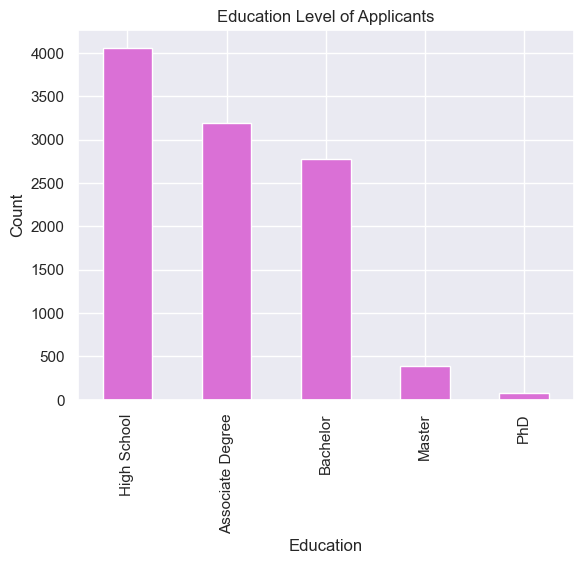

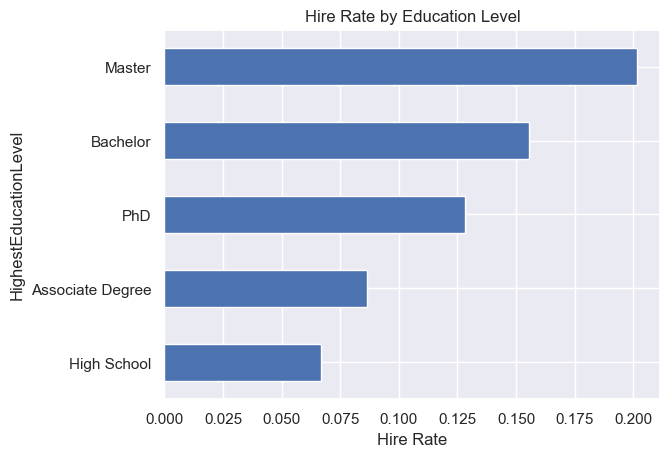

In [21]:
applicants["HighestEducationLevel"].value_counts().plot(kind="bar", color="orchid")
plt.title("Education Level of Applicants")
plt.xlabel("Education")
plt.ylabel("Count")
plt.show()

applicants.groupby("HighestEducationLevel")["Hired"].mean().sort_values().plot(kind="barh")
plt.title("Hire Rate by Education Level")
plt.xlabel("Hire Rate")
plt.show()

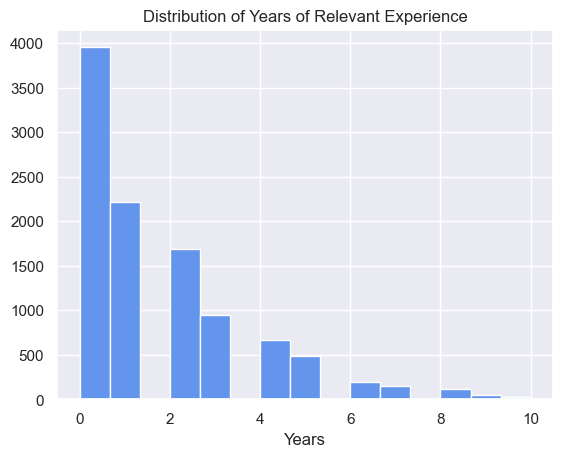

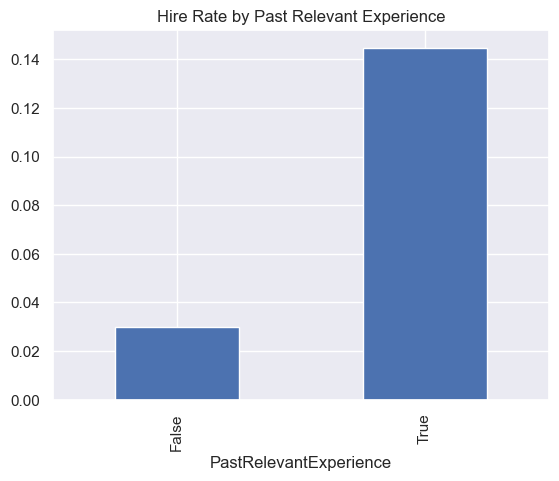

In [22]:
applicants["YearsOfRelevantExperience"].hist(bins=15, color="cornflowerblue")
plt.title("Distribution of Years of Relevant Experience")
plt.xlabel("Years")
plt.show()

applicants.groupby("PastRelevantExperience")["Hired"].mean().plot(kind="bar")
plt.title("Hire Rate by Past Relevant Experience")
plt.show()

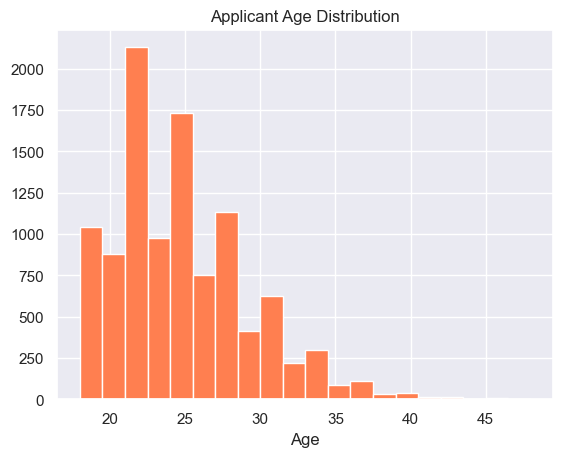

count    10500.000000
mean        24.531333
std          4.421487
min         18.000000
25%         21.000000
50%         24.000000
75%         27.000000
max         48.000000
Name: Age, dtype: float64


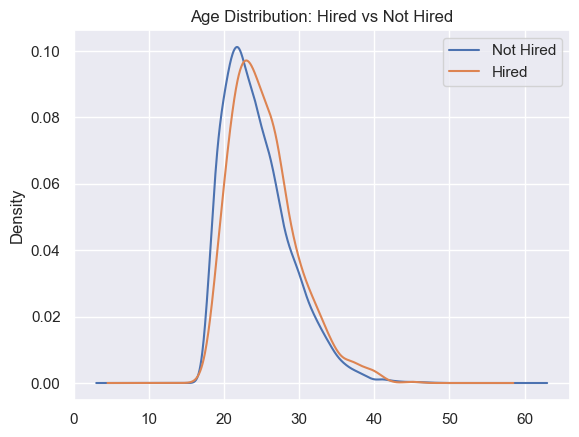

In [23]:
current_year = date.today().year
applicants["Age"] = current_year - applicants["YearOfBirth"]
applicants["Age"].hist(bins=20, color="coral")
plt.title("Applicant Age Distribution")
plt.xlabel("Age")
plt.show()

print(applicants["Age"].describe())

applicants.groupby("Hired")["Age"].plot(kind="kde")
plt.title("Age Distribution: Hired vs Not Hired")
plt.legend(["Not Hired", "Hired"])
plt.show()

### Branches

In [24]:
branch.info()

<class 'pandas.DataFrame'>
RangeIndex: 1049 entries, 0 to 1048
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Branch#     1049 non-null   int64         
 1   BranchName  1049 non-null   str           
 2   Latitude    1049 non-null   float64       
 3   Longitude   1049 non-null   float64       
 4   ReviewText  1049 non-null   str           
 5   Stars       1049 non-null   int64         
 6   DatePosted  1049 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(2), int64(2), str(2)
memory usage: 57.5 KB


In [25]:
print("Duplicate rows:", branch.duplicated().sum())

Duplicate rows: 0


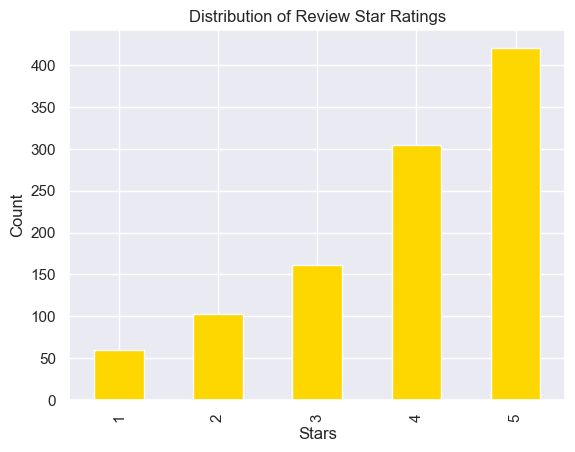

count    1049.000000
mean        3.882745
std         1.200579
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         5.000000
Name: Stars, dtype: float64


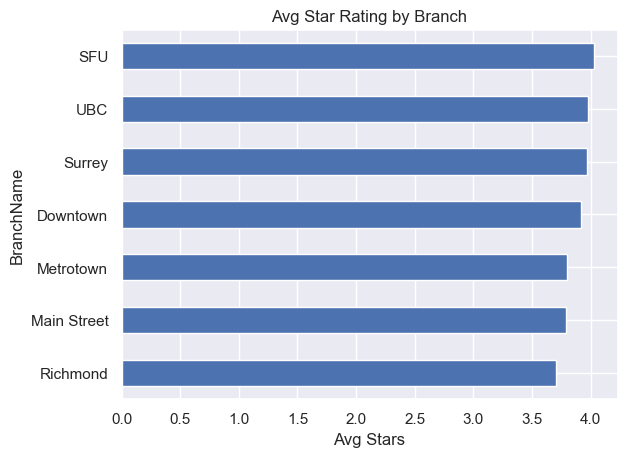

,Branch#,BranchName,NumReviews
0,1,UBC,149
1,2,SFU,150
2,3,Downtown,150
3,4,Main Street,150
4,5,Richmond,150
5,6,Surrey,150
6,7,Metrotown,150


In [26]:
branch["Stars"].value_counts().sort_index().plot(kind="bar", color="gold")
plt.title("Distribution of Review Star Ratings")
plt.xlabel("Stars")
plt.ylabel("Count")
plt.show()

print(branch["Stars"].describe())

branch.groupby("BranchName")["Stars"].mean().sort_values().plot(kind="barh")
plt.title("Avg Star Rating by Branch")
plt.xlabel("Avg Stars")
plt.show()

branch.groupby(["Branch#", "BranchName"]).size().reset_index(name="NumReviews")

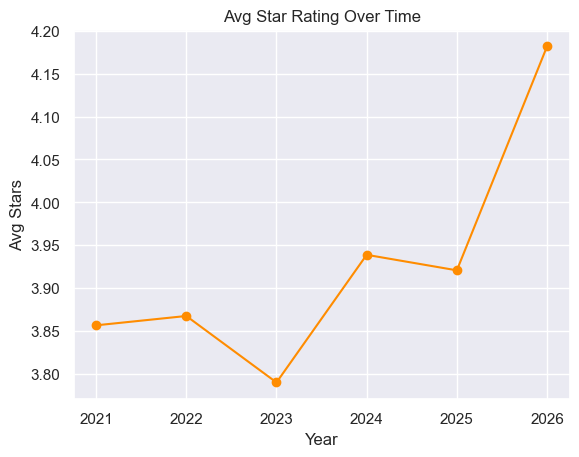

In [27]:
branch["PostYear"] = branch["DatePosted"].dt.year

branch.groupby("PostYear")["Stars"].mean().plot(marker="o", color="darkorange")
plt.title("Avg Star Rating Over Time")
plt.ylabel("Avg Stars")
plt.xlabel("Year")
plt.show()

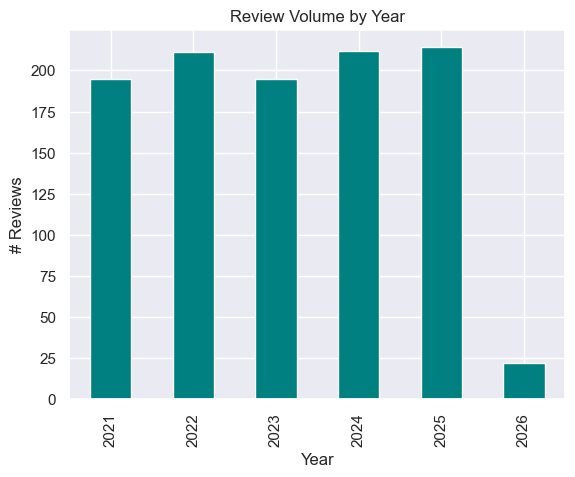

In [28]:
branch["PostYear"].value_counts().sort_index().plot(kind="bar", color="teal")
plt.title("Review Volume by Year")
plt.xlabel("Year")
plt.ylabel("# Reviews")
plt.show()

In [29]:
quit_ids = changes[changes["New Role"] == "Quit"]["EmployeeID"]
still_working = employees[
    employees["EmployeeID"].isin(quit_ids) & (employees["Current status"] == "Working")
]
print(f"Employees marked as Quit in changes but still Working in employees: {len(still_working)}")

Employees marked as Quit in changes but still Working in employees: 0
